In [1]:
# interactive figure
%matplotlib widget

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import dask
import shutil
import warnings
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import matplotlib.gridspec as gridspec
from sys import platform
from streamjoy import stream, wrap_matplotlib
from viztool import FormatScalarFormatter, pcolor_center, pcolor_limits, create_register_cmaps, div_sym_cmap
from dask.distributed import LocalCluster, Client
from dask_jobqueue import PBSCluster
from matplotlib.colors import LinearSegmentedColormap

import streamjoy
streamjoy.config['fps'] = 5
streamjoy.config['codec'] = 'h264' #'libx264'
streamjoy.config['display'] = False
streamjoy.config['max_frames'] = -1
streamjoy.config['batch_size'] = 10
streamjoy.config['processes'] = True #False
streamjoy.config['ending_pause'] = 0
streamjoy.config['threads_per_worker'] = 1
streamjoy.config['scratch_dir'] = '/glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Animations/streamjoy_scratch'

In [3]:
if platform == 'linux' or platform == 'linux2':
    data_dir = '/glade/derecho/scratch/zhihuaz/TracerInversion/Output/'
elif platform == 'darwin':
    data_dir = '/Users/zhihua/Documents/Work/Research/Projects/TRACE-SEAS/TracerInversion//Data/'
else:
    print('OS not supported.')

create_register_cmaps(extreme=False)

In [5]:
bname = 'd11_M009_Ri040_em01'
# cname = bname+'_Q010_W000_D000_St0'
# cname = bname + '_Q001_W000_D000_St0_with-tracer-fluxed'
# cname = bname + '_Q001_W000_D000_St0_init-tracer-fluxed'
cname = bname + '_spinup'

ds = xr.open_dataset('/glade/derecho/scratch/zhihuaz/TracerInversion/Output/'+cname+'_top.nc',
                     decode_timedelta=True).chunk(time=5, zC=4)
ds.close()

# ds0 = xr.open_dataset('/glade/derecho/scratch/zhihuaz/TracerInversion/Output/'+cname+'_south.nc',
#                      decode_timedelta=True).chunk(time=5, zC=4)
# ds1 = xr.open_dataset('/glade/derecho/scratch/zhihuaz/TracerInversion/Output/'+cname.replace('init','with')+'_state.nc',
#                      decode_timedelta=True).isel(yC=slice(0,1)).chunk(time=5, zC=4)

# ds0 = xr.open_dataset('/glade/derecho/scratch/zhihuaz/TracerInversion/Output/'+cname+'_xfcr.nc',
#                      decode_timedelta=True).chunk(time=5, zC=4)
# ds1 = xr.open_dataset('/glade/derecho/scratch/zhihuaz/TracerInversion/Output/'+cname.replace('init','with')+'_state.nc',
#                      decode_timedelta=True).isel(xC=slice(1499,1500)).chunk(time=5, zC=4)
# ds0.close()
# ds1.close()
# ds = xr.concat([ds0, ds1], dim='time')

ds['day'] = ds.time/np.timedelta64(1, 'D')
# ds['timeTf'] = ds.time/np.timedelta64(int(np.around(2*np.pi/1e-4)), 's')
ds['xC'] = ds.xC/1e3
ds['yC'] = ds.yC/1e3
ds

<xarray.Dataset> Size: 15GB
Dimensions:  (zC: 1, zF: 1, xC: 2000, yF: 1000, xF: 2000, yC: 1000, time: 481)
Coordinates:
  * zC       (zC) float32 4B -11.04
  * zF       (zF) float32 4B -11.89
  * xC       (xC) float32 8kB -3.998 -3.994 -3.99 -3.986 ... 3.99 3.994 3.998
  * yF       (yF) float32 4kB 0.0 4.0 8.0 12.0 ... 3.988e+03 3.992e+03 3.996e+03
  * xF       (xF) float32 8kB -4e+03 -3.996e+03 ... 3.992e+03 3.996e+03
  * yC       (yC) float32 4kB 0.002 0.006 0.01 0.014 ... 3.986 3.99 3.994 3.998
  * time     (time) timedelta64[ns] 4kB 00:00:00 00:30:00 ... 10 days 00:00:00
Data variables:
    v        (time, zC, yC, xC) float32 4GB dask.array<chunksize=(5, 1, 1000, 2000), meta=np.ndarray>
    w        (time, zC, yC, xC) float32 4GB dask.array<chunksize=(5, 1, 1000, 2000), meta=np.ndarray>
    b        (time, zC, yC, xC) float32 4GB dask.array<chunksize=(5, 1, 1000, 2000), meta=np.ndarray>
    u        (time, zC, yC, xC) float32 4GB dask.array<chunksize=(5, 1, 1000, 2000), meta=np.ndarray>
    day      (time) float64 4kB 0.0 0.02083 0.04167 0.0625 ... 9.958 9.979 10.0
Attributes: (12/78)
    σ_wind:                 0
    Ly:                     4000.0
    init_tracer:            0
    use_Stokes:             0
    n_per_set:              3.0
    save_ckp_interval:      86400.0
    ...                     ...
    tracer_reset_interval:  1
    Ny:                     1000
    output_prefix:          d11_M009_Ri040_em01_spinup
    Oceananigans:           This file was generated using Oceananigans v0.95.12
    RiB₁:                   40.0
    ckp_prefix:             spinup

In [5]:
from xgcm import Grid

periodic_coords = {dim : dict(left=f'{dim}F', center=f'{dim}C') for dim in 'xy'}
bounded_coords = {dim : dict(outer=f'{dim}F', center=f'{dim}C') for dim in 'z'}
coords = {dim : periodic_coords[dim] if tpl=='P' else bounded_coords[dim] for dim, tpl in zip('xyz', 'PPN')}
grid = Grid(ds, coords=coords)
dxF = ds.xF.diff('xF').data[0]
dyF = ds.yF.diff('yF').data[0]
# dzF = ds.zF.diff('zF').data

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    b_xf = grid.interp(ds.b, axis='x').transpose(..., 'xF')
    b_yf = grid.interp(ds.b, axis='y').transpose(..., 'yF')
    # b_zf = grid.interp(ds.b, axis='z', boundary='extend').transpose(..., 'zF')
    u_xf = grid.interp(ds.u, axis='x').transpose(..., 'xF')
    u_yf = grid.interp(ds.u, axis='y').transpose(..., 'yF')
    # u_zf = grid.interp(ds.u, axis='z', boundary='extend').transpose(..., 'zF')
    v_xf = grid.interp(ds.v, axis='x').transpose(..., 'xF')
    v_yf = grid.interp(ds.v, axis='y').transpose(..., 'yF')
    # v_zf = grid.interp(ds.v, axis='z', boundary='extend').transpose(..., 'zF')

    ds['dbdx'] = grid.diff(b_xf, axis='x') / dxF
    ds['dbdy'] = grid.diff(b_yf, axis='y') / dyF
    # ds['dbdz'] = grid.diff(b_zf, axis='z') / dzF

    ds['dudx'] = grid.diff(u_xf, axis='x') / dxF
    ds['dudy'] = grid.diff(u_yf, axis='y') / dyF
    # ds['dudz'] = grid.diff(u_zf, axis='z') / dzF

    ds['dvdx'] = grid.diff(v_xf, axis='x') / dxF
    ds['dvdy'] = grid.diff(v_yf, axis='y') / dyF
    # ds['dvdz'] = grid.diff(v_zf, axis='z') / dzF

ds['ζ'] = ds.dvdx - ds.dudy
ds['δ'] = ds.dudx + ds.dvdy
ds['σₛ'] = ds.dvdx + ds.dudy
ds['σₙ'] = ds.dudx - ds.dvdy
ds['σ'] = np.sqrt(ds['σₛ']**2 + ds['σₙ']**2)
ds['M²'] = np.sqrt(ds['dbdx']**2 + ds['dbdy']**2)
# ds['Sh'] = np.sqrt(ds['dudz']**2 + ds['dvdz']**2)

In [20]:
@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_w_b_xy(ds, **kwargs):
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    depth  = kwargs.pop('depth', 10)
    w, b   = ds.w, ds.b
    day    = ds.day.item()
    fig,ax = plt.subplots(2,1, figsize=(6.5, 6), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    pcm0,_ = pcolor_center(w, ax[0], cmap=plt.get_cmap('RdBu_r', 32), smag=8e-4)
    pcm1,_ = pcolor_limits(b, ax[1], cmap=plt.get_cmap('Spectral_r', 45), clim=[2.953e-3, 3.002e-3])
    pcms  = [pcm0, pcm1]
    cstrs = [r'$w$ [m s$^{-1}$]', r'Buoyancy $b$ [m s$^{-2}$]']
    cbar_kwargs = [dict(), dict()]
    for i in range(2):
        cbar = fig.colorbar(pcms[i], ax=ax[i], location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs[i])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.ax.locator_params(nbins=5)
        
        cbar.formatter.set_powerlimits((0, 0))
        offset_text = cbar.ax.yaxis.get_offset_text()
        offset_text.set_fontsize(5)
        offset_text.set_horizontalalignment('left')
        offset_text.set_verticalalignment('top')
        offset_text.set_position((1, 0))
        
        cbar.set_label(label=rf"{cstrs[i]}", size=8)
        ax[i].tick_params(axis='both', which='major', labelsize=6)
        ax[i].set_ylabel(r'$y$ [km]')
        ax[i].set_yticks(np.linspace(0,4,5))
        ax[i].set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ {depth} m depth', fontsize=8)
    ax[1].set_xticks(np.linspace(-4,4,9))
    ax[1].set_xlabel(r'$x$ [km]')
    return fig

@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_two_tracers_xy(ds, **kwargs):
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    depth  = kwargs.pop('depth', 10)
    c7, c8 = ds.c7, ds.c8
    day    = ds.day.item()
    fig,ax = plt.subplots(2,1, figsize=(6.5, 6), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    pcm0,_ = pcolor_limits(c7, ax[0], cmap=plt.get_cmap('turbo', 10), clim=[0, 0.1])
    pcm1,_ = pcolor_limits(c8, ax[1], cmap=plt.get_cmap('turbo', 20), clim=[0, 1])
    pcms  = [pcm0, pcm1]
    cstrs = [r'Nutrient tracer $c_7$', r'Surface fluxed tracer $c_8$']
    cbar_kwargs = [dict(), dict(extend='min')]
    for i in range(2):
        cbar = fig.colorbar(pcms[i], ax=ax[i], location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs[i])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.ax.locator_params(nbins=5)
        cbar.set_label(label=rf"{cstrs[i]}", size=8)
        ax[i].tick_params(axis='both', which='major', labelsize=6)
        ax[i].set_ylabel(r'$y$ [km]')
        ax[i].set_yticks(np.linspace(0,4,5))
        ax[i].set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ {depth} m depth', fontsize=8)
    ax[1].set_xticks(np.linspace(-4,4,9))
    ax[1].set_xlabel(r'$x$ [km]')
    return fig

cmap_cds = div_sym_cmap(0.1, base='c')
@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_w_tracer_xy(ds, **kwargs):
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    depth  = kwargs.pop('depth', 10)
    w, c8  = ds.w, ds.c8
    day    = ds.day.item()
    fig,ax = plt.subplots(2,1, figsize=(6.5, 6), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    bounds = np.linspace(-4e-3, 4e-3, 17)
    norm   = mcl.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')
    pcm0,_ = pcolor_center(w*c8, ax[0], cmap=cmap_cds, norm=norm)
    # bounds = np.linspace(-4e-3, 4e-3, 9)
    # norm   = mcl.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')
    # pcm1,_ = pcolor_center(w*c8, ax[1], cmap='PRGn_r', norm=norm)
    pcm1,_ = pcolor_limits(c8, ax[1], cmap=plt.get_cmap('turbo', 20), clim=[0, 1])
    pcms  = [pcm0, pcm1]
    # cstrs = [r'$w$ [m s$^{-1}$]', r'Surface fluxed tracer $c_8$']
    # cstrs = [r'$w$ [m s$^{-1}$]', r'Flux $wc_8$']
    cstrs = [r'Flux $wc_8$', r'Surface fluxed tracer $c_8$']
    cbar_kwargs = [dict(), dict(extend='min')]
    for i in range(2):
        cbar = fig.colorbar(pcms[i], ax=ax[i], location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs[i])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.ax.locator_params(nbins=5)
        #
        # cbar.formatter.set_powerlimits((0, 0))
        # offset_text = cbar.ax.yaxis.get_offset_text()
        # offset_text.set_fontsize(5)
        # offset_text.set_horizontalalignment('left')
        # offset_text.set_verticalalignment('top')
        # offset_text.set_position((1, 0))
        #
        cbar.set_label(label=rf"{cstrs[i]}", size=8)
        ax[i].tick_params(axis='both', which='major', labelsize=6)
        ax[i].set_ylabel(r'$y$ [km]')
        ax[i].set_yticks(np.linspace(0,4,5))
        ax[i].set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ {depth} m depth', fontsize=8)
    ax[1].set_xticks(np.linspace(-4,4,9))
    ax[1].set_xlabel(r'$x$ [km]')
    return fig

@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_zeta_tracer_xy(ds, **kwargs):
    import cmocean
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    depth  = kwargs.pop('depth', 10)
    zeta = ds['ζ'] / ds.f
    c8   = ds.c8
    day  = ds.day.item()
    fig,ax = plt.subplots(2,1, figsize=(6.5, 6), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    pcm0,_ = pcolor_center(zeta, ax[0], cmap='cmo.curl', smag=5)
    pcm1,_ = pcolor_limits(c8, ax[1], cmap=plt.get_cmap('turbo', 20), clim=[0, 1])

    pcms  = [pcm0, pcm1]
    cstrs = [r'Relative vorticity $\zeta$ / $f$', r'Surface fluxed tracer $c_8$']
    cbar_kwargs = [dict(), dict(extend='min')]
    for i in range(2):
        cbar = fig.colorbar(pcms[i], ax=ax[i], location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs[i])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.ax.locator_params(nbins=5)
        cbar.set_label(label=rf"{cstrs[i]}", size=8)
        ax[i].tick_params(axis='both', which='major', labelsize=6)
        ax[i].set_ylabel(r'$y$ [km]')
        ax[i].set_yticks(np.linspace(0,4,5))
        ax[i].set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ {depth} m depth', fontsize=8)
    ax[1].set_xticks(np.linspace(-4,4,9))
    ax[1].set_xlabel(r'$x$ [km]')
    return fig

cmap_delta = div_sym_cmap(0.1, base='RdBu_r')
@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_delta_tracer_xy(ds, **kwargs):
    import cmocean
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    depth = kwargs.pop('depth', 2)
    delta = ds['δ'] / ds.f
    c8    = ds.c8
    day   = ds.day.item()
    fig,ax = plt.subplots(2,1, figsize=(6.5, 6), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    bounds = np.linspace(-5, 5, 11)
    norm   = mcl.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')
    pcm0,_ = pcolor_center(delta, ax[0], cmap=cmap_delta, norm=norm)
    pcm1,_ = pcolor_limits(c8, ax[1], cmap=plt.get_cmap('turbo', 20), clim=[0, 1])

    pcms  = [pcm0, pcm1]
    cstrs = [r'Divergence $\delta$ / $f$', r'Surface fluxed tracer $c_8$']
    cbar_kwargs = [dict(), dict(extend='min')]
    for i in range(2):
        cbar = fig.colorbar(pcms[i], ax=ax[i], location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs[i])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.ax.locator_params(nbins=5)
        cbar.set_label(label=rf"{cstrs[i]}", size=8)
        ax[i].tick_params(axis='both', which='major', labelsize=6)
        ax[i].set_ylabel(r'$y$ [km]')
        ax[i].set_yticks(np.linspace(0,4,5))
        ax[i].set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ {depth} m depth', fontsize=8)
    ax[1].set_xticks(np.linspace(-4,4,9))
    ax[1].set_xlabel(r'$x$ [km]')
    return fig

@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_sigma_tracer_xy(ds, **kwargs):
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    depth = kwargs.pop('depth', 2)
    sigma = ds['σ'] / ds.f
    c8    = ds.c8
    day   = ds.day.item()
    fig,ax = plt.subplots(2,1, figsize=(6.5, 6), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    pcm0,_ = pcolor_limits(sigma, ax[0], cmap=plt.get_cmap('Reds', 10), clim=[0, 5])
    pcm1,_ = pcolor_limits(c8, ax[1], cmap=plt.get_cmap('turbo', 20), clim=[0, 1])

    pcms  = [pcm0, pcm1]
    cstrs = [r'Strain $\sigma$ / $f$', r'Surface fluxed tracer $c_8$']
    cbar_kwargs = [dict(), dict(extend='min')]
    for i in range(2):
        cbar = fig.colorbar(pcms[i], ax=ax[i], location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs[i])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.ax.locator_params(nbins=5)
        cbar.set_label(label=rf"{cstrs[i]}", size=8)
        ax[i].tick_params(axis='both', which='major', labelsize=6)
        ax[i].set_ylabel(r'$y$ [km]')
        ax[i].set_yticks(np.linspace(0,4,5))
        ax[i].set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ {depth} m depth', fontsize=8)
    ax[1].set_xticks(np.linspace(-4,4,9))
    ax[1].set_xlabel(r'$x$ [km]')
    return fig

cmapc = plt.get_cmap('c')
@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_tracer_xz(ds, **kwargs):
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    ydis  = kwargs.pop('ydis', 0)
    c8    = ds.c8
    day   = ds.day.item()
    fig,ax = plt.subplots(1,1, figsize=(6, 2), dpi=300, constrained_layout=True)
    bounds = np.linspace(0,1,21)
    norm   = mcl.BoundaryNorm(boundaries=bounds, ncolors=256)
    pcm,_ = pcolor_limits(c8, ax, cmap=cmapc, norm=norm)
    ax.contour(ds.xC, ds.zC, ds.b, levels=np.arange(3.23, 3.41, 0.02)*1e-4, colors='xkcd:black', linewidths=0.6)
    ax.contour(ds.xC, ds.zC, ds.b, levels=np.arange(2.60, 3.20, 0.06)*1e-4, colors='xkcd:grey',  linewidths=0.6, linestyles='--')
    cstrs = r'Surface fluxed tracer $c_8$'
    cbar_kwargs = dict()
    cbar = fig.colorbar(pcm, ax=ax, location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs)
    cbar.ax.tick_params(labelsize=6, length=1)
    cbar.ax.locator_params(nbins=6)
    cbar.set_label(label=rf"{cstrs}", size=8)
    ax.tick_params(axis='both', which='major', labelsize=6)
    # ax.set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ y = {ydis:1.2f} km', fontsize=8)
    ax.set_xticks(np.linspace(-3,-1,5))
    ax.set_xlabel(r'$x$ [km]')
    ax.set_yticks(np.linspace(-70,0,8))
    ax.set_ylabel(r'$z$ [m]')
    return fig

@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_tracer_yz(ds, **kwargs):
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    xdis  = kwargs.pop('xdis', 0)
    b     = ds.b.sel(xC=xdis,  method='nearest').sel(zC=slice(-70, 0))
    c8    = ds.c8.sel(xC=xdis, method='nearest').sel(zC=slice(-70, 0))
    day   = ds.day.item()
    fig,ax = plt.subplots(1,1, figsize=(6, 2), dpi=300, constrained_layout=True)
    bounds = np.linspace(0,1,21)
    norm   = mcl.BoundaryNorm(boundaries=bounds, ncolors=256)
    pcm,_ = pcolor_limits(c8, ax, cmap=cmapc, norm=norm)
    ax.contour(b.yC, b.zC, b, levels=np.arange(3.23, 3.41, 0.02)*1e-4, colors='xkcd:black', linewidths=0.6)
    ax.contour(b.yC, b.zC, b, levels=np.arange(2.60, 3.20, 0.06)*1e-4, colors='xkcd:grey',  linewidths=0.6, linestyles='--')
    cstrs = r'Surface fluxed tracer $c_8$'
    cbar_kwargs = dict()
    cbar = fig.colorbar(pcm, ax=ax, location='right', shrink=1, aspect=40, pad=0.02, **cbar_kwargs)
    cbar.ax.tick_params(labelsize=6, length=1)
    cbar.ax.locator_params(nbins=6)
    cbar.set_label(label=rf"{cstrs}", size=8)
    ax.tick_params(axis='both', which='major', labelsize=6)
    # ax.set_aspect('equal')
    fig.suptitle(rf'Day: {day:1.2f} @ x = {xdis:1.2f} km', fontsize=8)
    ax.set_xticks(np.linspace(0,4,5))
    ax.set_xlabel(r'$y$ [km]')
    ax.set_yticks(np.linspace(-70,0,8))
    ax.set_ylabel(r'$z$ [m]')
    return fig

In [ ]:
depth = 10
varlist = ['w', 'b', 'day']
plot_w_b_xy(ds[varlist].sel(zC=-depth, method='nearest').isel(time=240), depth=depth);

In [21]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
depth = 10
varlist = ['w', 'b', 'day']
stream([ds[varlist].sel(zC=-depth, method='nearest').isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_w_b_xy,
       renderer_kwargs=dict(depth=depth),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_wb_xy{depth:02d}.mp4');

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46743 instead
  warnings.warn(
[SUCCESS] 01:00PM: Saved stream to /glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Analysis/../Animations/d11_M009_Ri040_em01_spinup_wb_xy10.mp4.


CPU times: user 3min 19s, sys: 9.02 s, total: 3min 28s
Wall time: 2min 25s


In [ ]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
depth = 20
varlist = ['c7', 'c8', 'day']
stream([ds[varlist].sel(zC=-depth, method='nearest').isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_two_tracers_xy,
       renderer_kwargs=dict(depth=depth),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_c7c8_xy{depth:02d}.mp4');

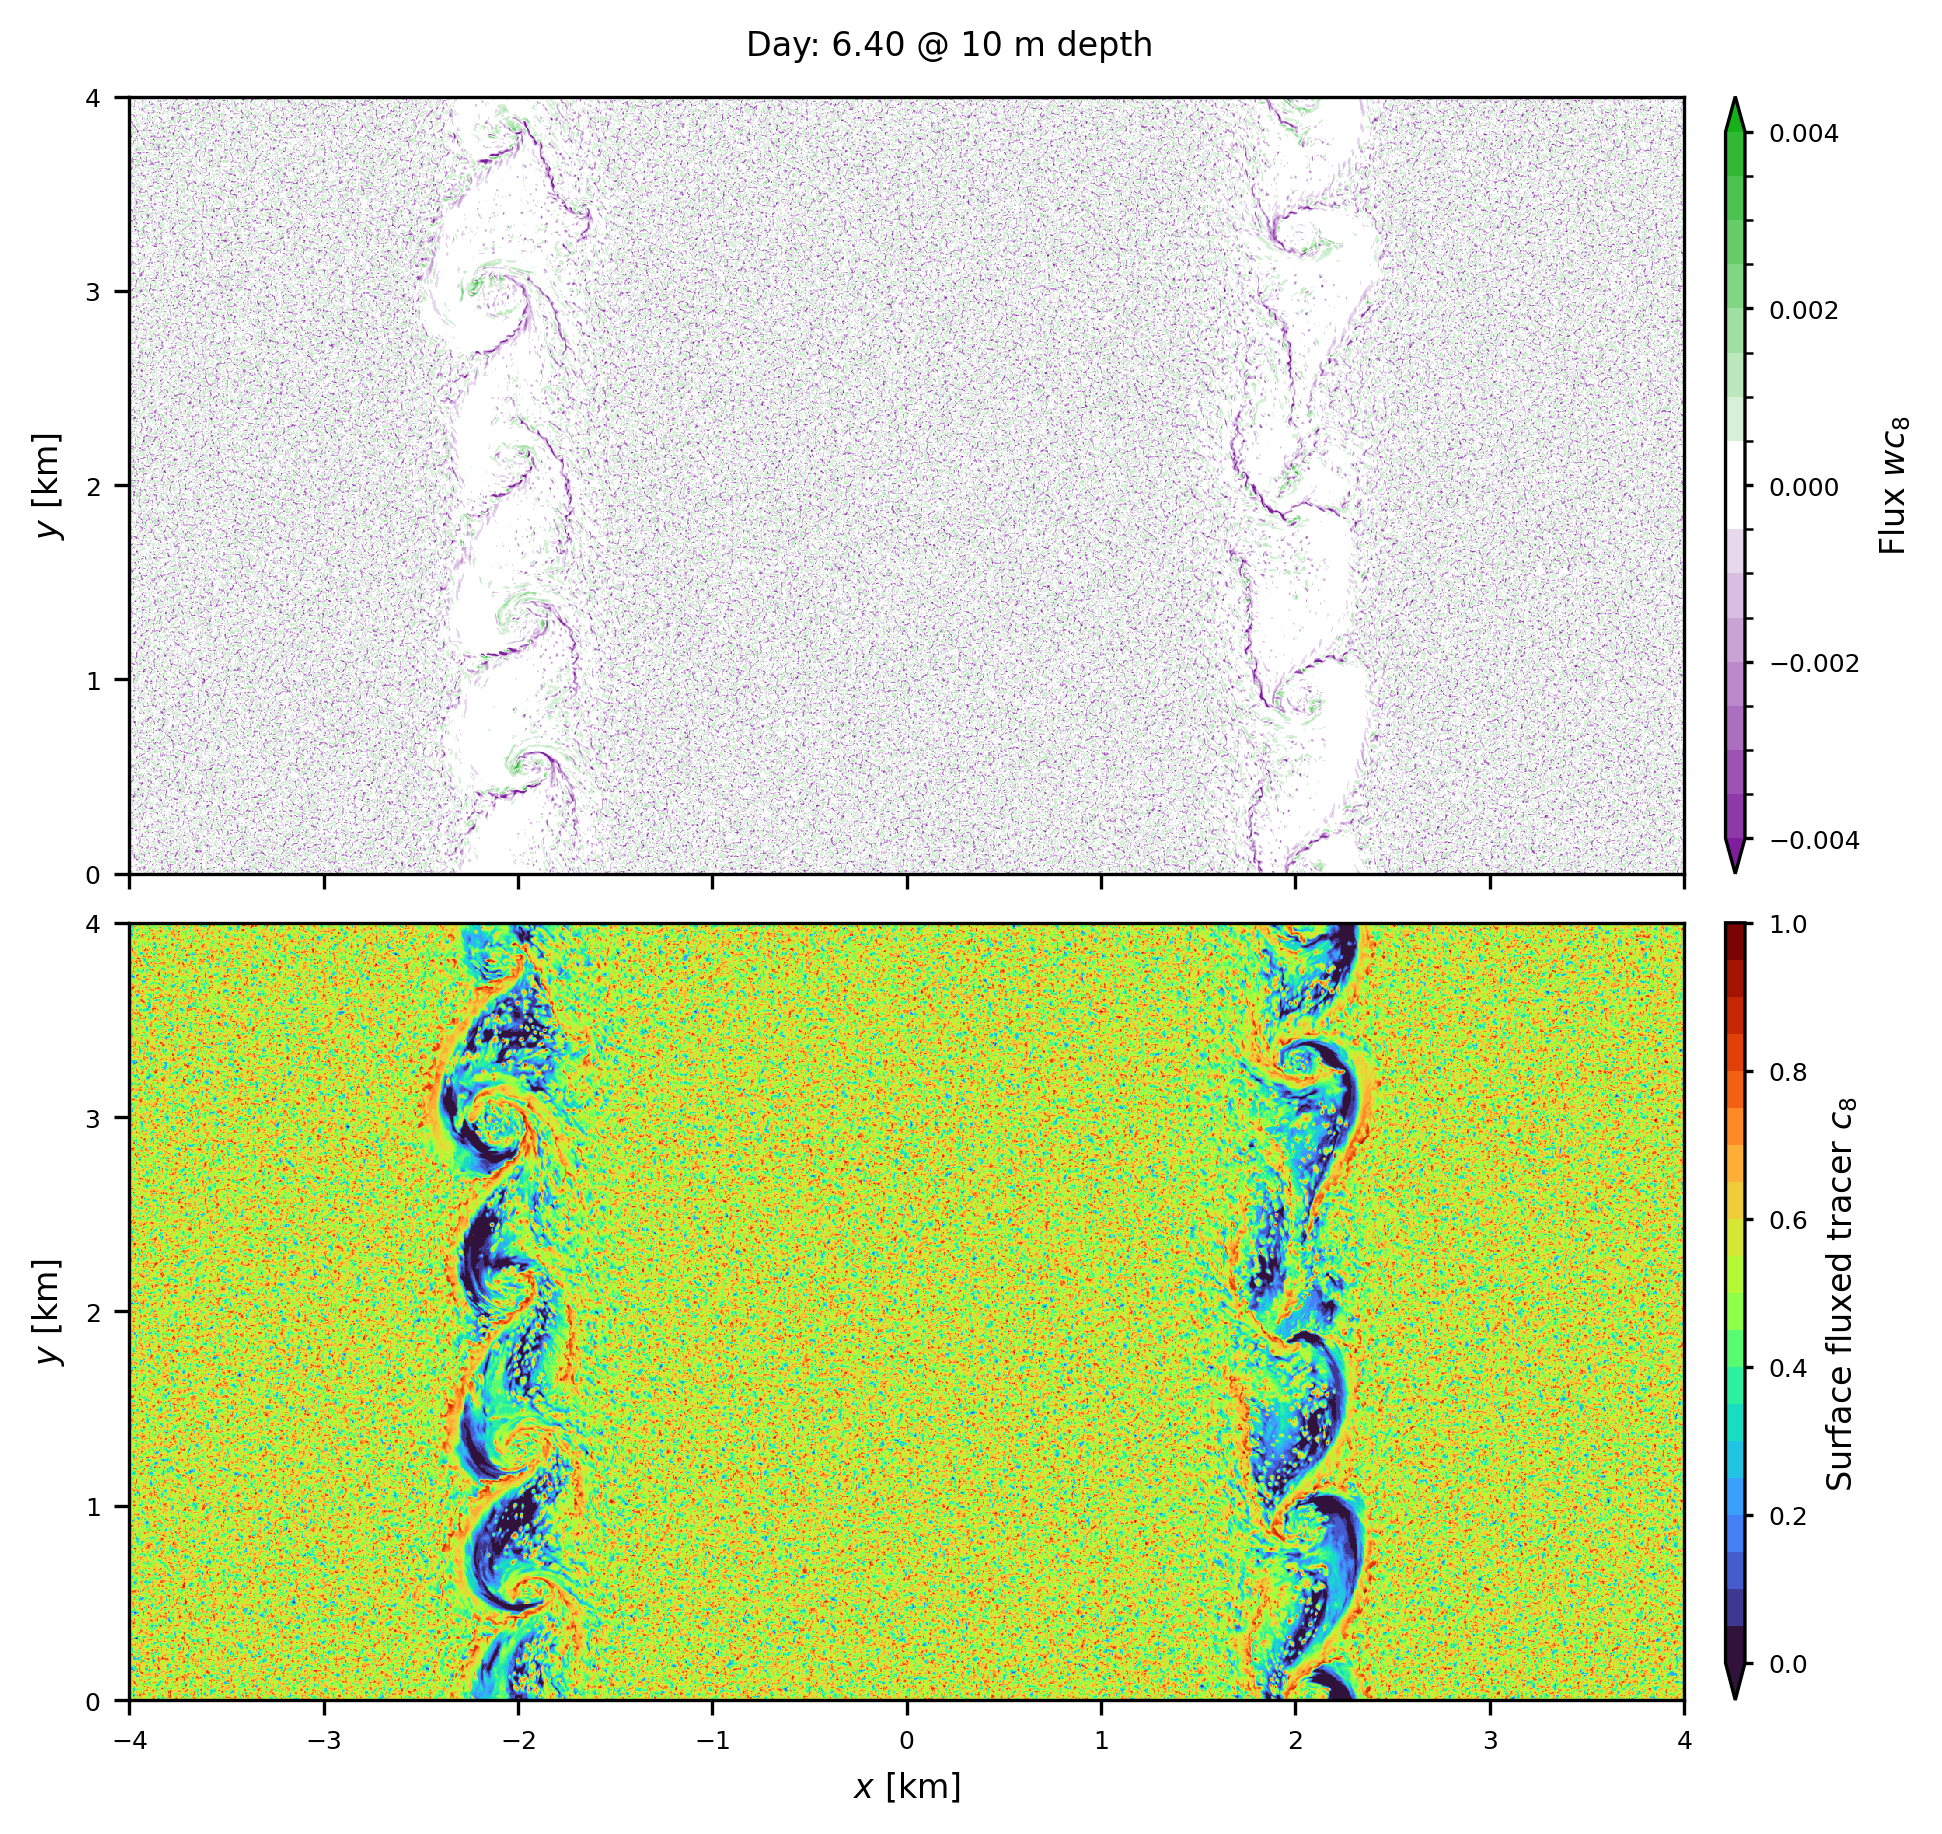

In [9]:
depth = 10
varlist = ['w', 'c8', 'day']
plot_w_tracer_xy(ds[varlist].sel(zC=-depth, method='nearest').isel(time=100), depth=depth);

In [ ]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
depth = 10
varlist = ['w', 'c8', 'day']
stream([ds[varlist].sel(zC=-depth, method='nearest').isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_w_tracer_xy,
       renderer_kwargs=dict(depth=depth),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_wc8_xy{depth:02d}.mp4');

In [24]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
depth = 2
varlist = ['ζ', 'c8', 'day']
stream([ds[varlist].sel(zC=-depth, method='nearest').isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_zeta_tracer_xy,
       renderer_kwargs=dict(depth=depth),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_zetac8_xy{depth:02d}.mp4');

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34107 instead
  warnings.warn(
[SUCCESS] 04:14PM: Saved stream to /glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Analysis/../Animations/d11_M003_Ri040_em01_Q001_W000_D000_St0_with-tracer-fluxed_zetac8_xy02.mp4.


CPU times: user 2min 27s, sys: 21.5 s, total: 2min 49s
Wall time: 2min 9s


In [ ]:
depth = 2
varlist = ['δ', 'c8', 'day']
plot_delta_tracer_xy(ds[varlist].sel(zC=-depth, method='nearest').isel(time=10), depth=depth)

In [11]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
depth = 2
varlist = ['δ', 'c8', 'day']
stream([ds[varlist].sel(zC=-depth, method='nearest').isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_delta_tracer_xy,
       renderer_kwargs=dict(depth=depth),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_deltac8_xy{depth:02d}.mp4');

/glade/work/zhihuaz/conda-envs/trace-seas/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44847 instead
  warnings.warn(
[SUCCESS] 07:23PM: Saved stream to /glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Analysis/../Animations/d11_M003_Ri040_em01_Q001_W000_D000_St0_with-tracer-fluxed_deltac8_xy02.mp4.


CPU times: user 2min 18s, sys: 6.23 s, total: 2min 25s
Wall time: 2min 16s


In [ ]:
depth = 2
varlist = ['σ', 'c8', 'day']
plot_sigma_tracer_xy(ds[varlist].sel(zC=-depth, method='nearest').isel(time=10), depth=depth);

In [7]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
depth = 2
varlist = ['σ', 'c8', 'day']
stream([ds[varlist].sel(zC=-depth, method='nearest').isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_sigma_tracer_xy,
       renderer_kwargs=dict(depth=depth),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_sigmac8_xy{depth:02d}.mp4');

[SUCCESS] 07:14PM: Saved stream to /glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Analysis/../Animations/d11_M003_Ri040_em01_Q001_W000_D000_St0_with-tracer-fluxed_sigmac8_xy02.mp4.


CPU times: user 2min 35s, sys: 5.61 s, total: 2min 40s
Wall time: 2min 22s


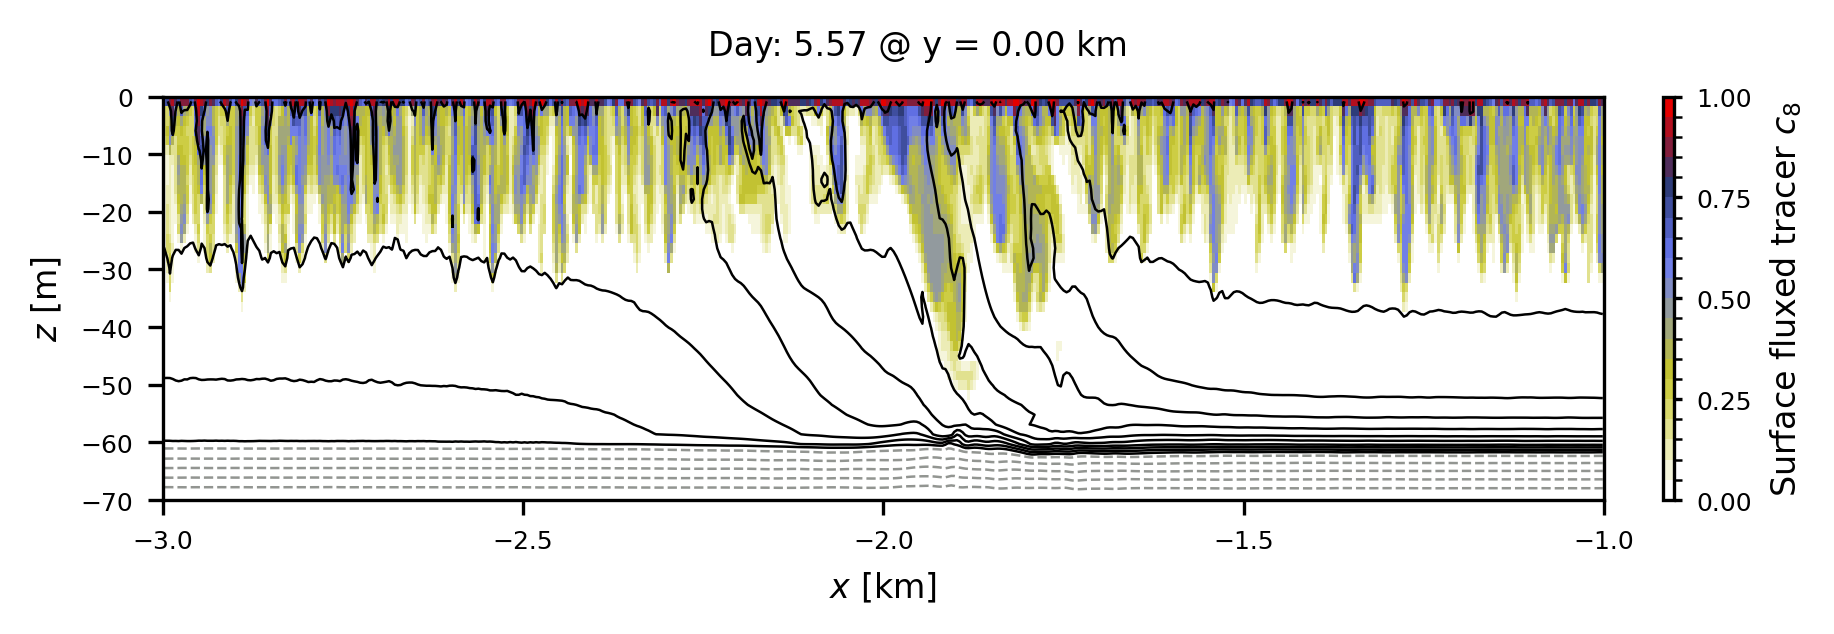

In [8]:
ydis = 0
varlist = ['b', 'c8', 'day']
plot_tracer_xz(ds[varlist].sel(yC=ydis, method='nearest').sel(xC=slice(-3, -1)).sel(zC=slice(-70, 0)).isel(time=40), ydis=ydis);

In [6]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
ydis = 0
varlist = ['b', 'c8', 'day']
stream([ds[varlist].sel(yC=ydis, method='nearest').sel(xC=slice(-3, -1)).sel(zC=slice(-70, 0)).isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_tracer_xz,
       renderer_kwargs=dict(ydis=ydis),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_c8_xz{ydis:02d}.mp4');

[SUCCESS] 04:59PM: Saved stream to /glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Analysis/../Animations/d11_M003_Ri040_em01_Q001_W000_D000_St0_init-tracer-fluxed_c8_xz00.mp4.


CPU times: user 2min 28s, sys: 6.91 s, total: 2min 35s
Wall time: 4min 28s


In [ ]:
xdis = 2
varlist = ['b', 'c8', 'day']
plot_tracer_yz(ds[varlist].isel(time=0), xdis=xdis);

In [6]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])
xdis = 2
varlist = ['b', 'c8', 'day']
stream([ds[varlist].isel(time=i) for i in range(ds.sizes['time'])],
       renderer=plot_tracer_yz,
       renderer_kwargs=dict(xdis=xdis),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_c8_yz{xdis:02d}.mp4');

[SUCCESS] 09:32PM: Saved stream to /glade/u/home/zhihuaz/Projects/TRACE-SEAS/TracerInversion/Analysis/../Animations/d11_M003_Ri040_em01_Q001_W000_D000_St0_init-tracer-fluxed_c8_yz02.mp4.


CPU times: user 1min 27s, sys: 4.63 s, total: 1min 32s
Wall time: 3min 16s


### Vertically integrated fine-scale kinetic energy budget

In [8]:
cname = 'd11_M009_Ri040_em01_Q001_W000_D000_St0_init-tracer-fluxed'

dsl = xr.open_mfdataset(data_dir + cname + '/hr*_filtered.nc', 
                        decode_timedelta=False, combine='nested', concat_dim='time').isel(time=slice(None,48)).chunk(time=6,zC=3)
dsl.close()

dsf = xr.open_mfdataset(data_dir + cname + '/hr*_Ifske_budget.nc', 
                        decode_timedelta=False, combine='nested', concat_dim='time').isel(time=slice(None,48)).chunk(time=6)
dsf.close()

dsl['xC'] = dsl.xC/1e3
dsl['yC'] = dsl.yC/1e3
dsf['xC'] = dsf.xC/1e3
dsf['yC'] = dsf.yC/1e3

dsf['hour'] = (dsf.time-dsf.time[0])/1e9/3600
dsf['IHSP'] = dsf['IHSP_δ'] + dsf['IHSP_σ']
dsf['IVSP'] = dsf['IVSP_w'] + dsf['IVSP_uv']
dsf['ISP']  = dsf['IHSP']   + dsf['IVSP']
dsf['bml']  = dsl.b.where(dsl.zC >= -60).mean('zC')

bmld = np.floor(90*dsl.attrs['N₁²'] * 1e6) / 1e2
bsrf = np.floor((60*dsl.attrs['N₀²'] + dsl.Lf*dsl.attrs['M²']) * 1e6) / 1e2 + bmld
delb0 = np.floor((bsrf - bmld)/12 * 1e2) / 1e2
blines_upper = np.arange(bmld, bsrf, delb0)*1e-4

In [20]:
def config_colorbar(pcm, ax):
    cbar = plt.colorbar(pcm, ax=ax, location='right', shrink=1, aspect=50, pad=0.02)
    cbar.ax.tick_params(labelsize=6, length=2)
    cbar.formatter.set_powerlimits((0, 0))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set_fontsize(7)
    offset_text.set_horizontalalignment('left')
    offset_text.set_verticalalignment('bottom')
    offset_text.set_position((0, 1))

@wrap_matplotlib(scratch_dir=streamjoy.config['scratch_dir'])
def plot_Ifske_budget(ds, **kwargs):
    # import cmocean
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['savefig.bbox'] = 'tight'
    blines = kwargs.pop('blines')
    hour   = int(ds.hour.item())
    
    fig,ax = plt.subplots(1,4, figsize=(11, 5), dpi=300, constrained_layout=True, sharex=True, sharey=True)
    pcm0,_ = pcolor_limits(ds.Ifske, ax[0], cmap=plt.get_cmap('BuGn',9), clim=[0, 9e-4])
    _,_    = pcolor_center((ds.ISP + ds.IVBP), ax[1], cmap=plt.get_cmap('RdBu_r',15), smag=7e-8)
    pcm1,_ = pcolor_center(ds.ISP,  ax[2], cmap=plt.get_cmap('RdBu_r',15), smag=7e-8)
    _,_    = pcolor_center(ds.IVBP, ax[3], cmap=plt.get_cmap('RdBu_r',15), smag=7e-8)

    config_colorbar(pcm0, ax[0])
    config_colorbar(pcm1, ax[1:])
    txt_strs = [r"$\mathcal{E}\,'$", r"$\Pi + \mathcal{B}\,'$", r'$\Pi$', r"$\mathcal{B}\,'$"]
    for j in range(4):
        ax[j].contour(ds.xC, ds.yC, ds.bml, blines_upper, colors='k', linewidths=0.6)
        ax[j].text(0.04, 0.02, txt_strs[j], ha='left', va='bottom', transform=ax[j].transAxes, fontsize=12, fontweight='bold',
               bbox=dict(facecolor='w', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.3'))
        ax[j].set_aspect('equal')
        ax[j].set_xlabel(r'$x$ [km]')
    ax[0].text(0.98, 0.98, rf'Hour: {hour:02d}', ha='right', va='top', transform=ax[0].transAxes, fontsize=12)
    ax[0].set_yticks(np.linspace(0,4,5))
    ax[0].set_xticks(np.linspace(-3,-1,3))
    ax[0].set_ylabel(r'$y$ [km]')
    return fig

In [ ]:
x1, x2 = -3, -1
varlist = ['Ifske', 'ISP', 'IVBP', 'bml', 'hour']
plot_Ifske_budget(dsf[varlist].sel(xC=slice(x1, x2)).isel(time=10), blines=blines_upper);

In [ ]:
%%time
if os.path.isdir(streamjoy.config['scratch_dir']):
    shutil.rmtree(streamjoy.config['scratch_dir'])

x1, x2 = -3, -1
varlist = ['Ifske', 'ISP', 'IVBP', 'bml', 'hour']
stream([dsf[varlist].sel(xC=slice(x1, x2)).isel(time=i) for i in range(dsf.sizes['time'])],
       renderer=plot_Ifske_budget,
       renderer_kwargs=dict(blines=blines_upper),
       write_kwargs=dict(crf='18'),
       client=Client(),
       uri='../Animations/' + cname + f'_Ifske_budget.mp4');